 # 1 - Propagation of Hail-Induced Degradation Uncertainty to Energy Yield - Simplified and PySAM Models

This notebook evaluates how uncertainty in hail-induced increases in photovoltaic degradation propagates to lifetime energy yield. An empirical cumulative distribution function (CDF) of additional performance loss rate (PLR) following ≥1-inch hail events is used to sample degradation increases within a Monte Carlo framework.

The workflow is implemented in two stages:

1. **Simplified yield model** – A lightweight analytical model is used to verify the Monte Carlo framework and quantify how degradation uncertainty broadens the distribution of lifetime energy (e.g., P50 and P90).
2. **PySAM implementation** – The same degradation scenarios are applied to PySAM lifetime simulations to evaluate the resulting impact using a physics-based energy model.

The objective is to isolate and quantify the contribution of hail-induced degradation uncertainty to lifetime energy yield uncertainty before extending the methodology to more comprehensive techno-economic analyses.

In [1]:
#Imports
import PV_ICE
import pandas as pd
import numpy as np
import json
import os
import tqdm

In [2]:
# This information helps with debugging and getting support :)
import sys, platform
print("Working on a ", platform.system(), platform.release())
print("Python version ", sys.version)
print("Pandas version ", pd.__version__)
print("PV_ICE version ", PV_ICE.__version__)

Working on a  Windows 11
Python version  3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Pandas version  2.2.3
PV_ICE version  0.2.1.dev710+g684c1eea6.d20260402


## 1. Simplified Yield Model

In [3]:
# Load hail-induced PLR increase CDF
cdf_df = pd.read_csv("plr_increase_after_1in_hail.csv")

x = cdf_df["plr_percent_increase_peryear"].to_numpy(dtype=float)
y = cdf_df["cumulative_probability"].to_numpy(dtype=float)

# Safety checks
assert np.all(np.diff(y) >= 0), "CDF y-values must be nondecreasing"
assert y[0] >= 0 and y[-1] <= 1.0 + 1e-9, "CDF must stay within [0,1]"

# Normalize in case final point is not exactly 1
y = y / y[-1]

def sample_from_empirical_cdf(x_vals, cdf_vals, rng=None):
    """
    Inverse-CDF sampler from an empirical CDF.
    Returns one sampled PLR increase value (%/year).
    """
    if rng is None:
        rng = np.random.default_rng()
    u = rng.uniform()
    return np.interp(u, cdf_vals, x_vals)

In [4]:
# Generate shared Monte Carlo degradation scenarios
# These same degradation vectors will be used by both the simplified yield model
# and the PySAM model so the results are directly comparable.

rng = np.random.default_rng(123)

n_sims = 10000
analysis_period = 25
hail_year = 5              # example: storm happens at start of year 5
baseline_deg = 0.50        # %/year baseline degradation
p_increase = 0.57          # probability of added degradation after hail

extra_deg_samples = np.zeros(n_sims)
deg_vectors = np.full((n_sims, analysis_period), baseline_deg)

for i in range(n_sims):
    hit = rng.uniform() < p_increase
    if hit:
        delta_deg = sample_from_empirical_cdf(x, y, rng=rng)
    else:
        delta_deg = 0.0
    
    extra_deg_samples[i] = delta_deg
    deg_vectors[i, hail_year-1:] = baseline_deg + delta_deg  # hail year onward

In [5]:
year1_energy = 1.0

annual_energy = np.zeros((n_sims, analysis_period))

for i in range(n_sims):
    remaining = 1.0
    for yr in range(analysis_period):
        if yr == 0:
            annual_energy[i, yr] = year1_energy
        else:
            remaining *= (1 - deg_vectors[i, yr-1] / 100.0)
            annual_energy[i, yr] = year1_energy * remaining

lifetime_energy = annual_energy.sum(axis=1)

p50 = np.percentile(lifetime_energy, 50)
p90 = np.percentile(lifetime_energy, 10)   # finance convention: exceeded with 90% probability
p95 = np.percentile(lifetime_energy, 5)

print("Toy model results")
print("P50 lifetime energy:", p50)
print("P90 lifetime energy:", p90)
print("P95 lifetime energy:", p95)
print("Std dev:", lifetime_energy.std())

Toy model results
P50 lifetime energy: 22.93932724436673
P90 lifetime energy: 20.501130555477037
P95 lifetime energy: 19.234110868209378
Std dev: 1.3816372986264482


In [6]:
baseline_matrix = np.full((n_sims, analysis_period), baseline_deg)

baseline_annual_energy = np.zeros((n_sims, analysis_period))
for i in range(n_sims):
    remaining = 1.0
    for yr in range(analysis_period):
        if yr == 0:
            baseline_annual_energy[i, yr] = year1_energy
        else:
            remaining *= (1 - baseline_matrix[i, yr-1] / 100.0)
            baseline_annual_energy[i, yr] = year1_energy * remaining

baseline_lifetime_energy = baseline_annual_energy.sum(axis=1)

print("\nBaseline (no hail-induced extra PLR)")
print("P50:", np.percentile(baseline_lifetime_energy, 50))
print("P90:", np.percentile(baseline_lifetime_energy, 10))
print("Std dev:", baseline_lifetime_energy.std())

print("\nSpread increase")
print("Delta P50:", np.percentile(lifetime_energy, 50) - np.percentile(baseline_lifetime_energy, 50))
print("Delta P90:", np.percentile(lifetime_energy, 10) - np.percentile(baseline_lifetime_energy, 10))
print("Delta std:", lifetime_energy.std() - baseline_lifetime_energy.std())


Baseline (no hail-induced extra PLR)
P50: 23.555951410239732
P90: 23.555951410239732
Std dev: 7.105427357601002e-15

Spread increase
Delta P50: -0.6166241658730023
Delta P90: -3.0548208547626956
Delta std: 1.3816372986264411


## 2. PySAM Implementation

In [7]:
import PySAM
from PySAM import Pvsamv1 as pv
from PySAM import Pvwattsv8 as pvwatts
from PySAM import Cashloan as com
from PySAM import Grid as grid
from PySAM import Utilityrate5 as ur
import PySAM.Pvsamv1Tools as pvtools
import PySAM.ResourceTools as tools

print("PySAM version ", PySAM.__version__)

PySAM version  7.1.0


In [8]:
# Load SAM Json Files
pv_model = pv.default("FlatPlatePVCommercial")
ur_model = ur.from_existing(pv_model)
grid_model = grid.from_existing(pv_model)
fin_model = com.from_existing(pv_model)

for json_file in os.listdir('PBL 1_Data'):
    # get the inputs from the JSON file
    with open( 'PBL 1_Data/' + json_file, 'r') as f:
            pv_inputs = json.load( f )
    
    # iterate through the input key-value pairs and set the module inputs
    for k, v in pv_inputs.items():
        if k != 'number_inputs':
            try:
                pv_model.value(k, v)
            except:
                try:
                    ur_model.value(k, v)
                except:
                    try:
                        grid_model.value(k, v)
                    except:
                        try:
                            fin_model.value(k, v)
                        except:
                            print("Variable not found in modules")

# grid_model = grid.from_existing(pv_model)
# ur_model = ur.from_existing(pv_model)
# fin_model = com.from_existing(pv_model)


In [9]:
# Assing Resource Weather Data
weather_file = "data/CA_weather_data.csv"
pv_model.SolarResource.solar_resource_file = weather_file

In [10]:
#Typical Execute
#pv_model.execute()
#grid_model.execute()
#ur_model.execute()
#fin_model.execute()


In [11]:
def run_one_pysam_case(deg_vector):
    # Pick a config that matches your base case
    # Example placeholder:
    m = pv.default("FlatPlatePVSingleOwner")
    m.SolarResource.solar_resource_file = weather_file
    # You must already have a known-good base model or exported JSON inputs
    # loaded here. If you already have a SAM case, using exported inputs is best.

    m.Lifetime.system_use_lifetime_output = 1
    m.Lifetime.analysis_period = len(deg_vector)
    m.Lifetime.dc_degradation = list(deg_vector)

    # Optional but often useful
    m.Lifetime.save_full_lifetime_variables = 1

    m.execute()

    # Choose outputs you care about; exact output names depend on model setup
    # Commonly inspect:
    outputs = m.Outputs.export()

    return outputs

In [14]:
# Number of degradation scenarios to evaluate with PySAM.
# Currently set to reuse the same vectors generated above from the simplified method
# Becuase of this, n_sims_pySAM should be be smaller than n_sims, and can be very small while testing to reduce runtime.
n_sims_pySAM = 5
lifetime_metric = []

if n_sims_pySAM > n_sims:
    raise ValueError(
        f"n_sims_pySAM ({n_sims_pySAM}) cannot exceed the number of "
        f"generated degradation scenarios ({n_sims})."
    )

for i in tqdm.tqdm(range(n_sims_pySAM), desc="Running PySAM Monte Carlo"):
    # THIS Would regenerate the degradation vectors; calling the previously generate dones from the simplified model
    #hit = rng.uniform() < p_increase
    #delta_deg = sample_from_empirical_cdf(x, y, rng) if hit else 0.0
    #deg_vec = np.full(analysis_period, baseline_deg)
    #deg_vec[hail_year-1:] = baseline_deg + delta_deg

    deg_vec = deg_vectors[i]
    out = run_one_pysam_case(deg_vec)

    total_gen = np.sum(out["gen"])   # one scalar only
    lifetime_metric.append(total_gen)

Running PySAM Monte Carlo: 100%|█████████████████████████████████████████████████████████| 5/5 [01:15<00:00, 15.08s/it]


N = 5
P50 = 5315443097.873214
P90 = 5303682151.102011
P95 = 5303240225.171334
Mean = 5310827104.350868
Std = 5696432.270993952


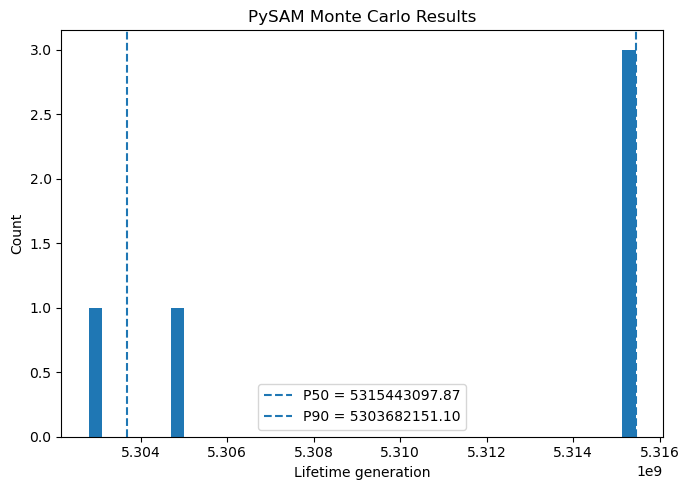

In [15]:
arr = np.array(lifetime_metric, dtype=float)

print("N =", len(arr))
print("P50 =", np.percentile(arr, 50))
print("P90 =", np.percentile(arr, 10))
print("P95 =", np.percentile(arr, 5))
print("Mean =", arr.mean())
print("Std =", arr.std())

import matplotlib.pyplot as plt

p50 = np.percentile(arr, 50)
p90 = np.percentile(arr, 10)

plt.figure(figsize=(7,5))
plt.hist(arr, bins=40)
plt.axvline(p50, linestyle="--", label=f"P50 = {p50:.2f}")
plt.axvline(p90, linestyle="--", label=f"P90 = {p90:.2f}")
plt.xlabel("Lifetime generation")
plt.ylabel("Count")
plt.title("PySAM Monte Carlo Results")
plt.legend()
plt.tight_layout()
plt.show()

### Sanity check - Selecting the appropriate PySAM output

Initially, the Monte Carlo results were evaluated using the `annual_energy` output, but this metric did not change between degradation scenarios. The following checks verify that the degradation vectors are correctly propagated through the PySAM simulation and identify which output is appropriate for quantifying lifetime energy uncertainty.

Two extreme degradation scenarios (no degradation vs. severe degradation after Year 4) are simulated to confirm that the model responds to changes in the degradation profile. The `annual_energy` output is first compared between the two cases and then the relevant PySAM outputs are inspected to determine which variables are sensitive to lifetime degradation.

These tests showed that `annual_energy` remained unchanged, whereas the time-series generation output (`gen`) varied between scenarios. Consequently, the lifetime generation, computed as `np.sum(gen)`, was selected as the metric for the Monte Carlo analysis.

In [17]:
# Generating two EXTREME test case, not realistic ones
deg_vec_A = [0.0] * 25  # No degradation ever
deg_vec_B = [0.0]*4 + [10.0]*21  # Absurd degradation after year 4

out_A = run_one_pysam_case(deg_vec_A)
out_B = run_one_pysam_case(deg_vec_B)

print("annual_energy A:", out_A.get("annual_energy"))
print("annual_energy B:", out_B.get("annual_energy"))

annual_energy A: 213294244.84460205
annual_energy B: 213294244.84460205


In [19]:
# Checking which outputs actually exist. 
keys = sorted(out_A.keys())
for k in keys:
    if any(s in k.lower() for s in ["annual", "gen", "energy", "lifetime", "cf"]):
        print(k, type(out_A[k]))

ac_lifetime_loss <class 'tuple'>
annual_ac_gross <class 'float'>
annual_ac_inv_clip_loss_percent <class 'float'>
annual_ac_inv_eff_loss_percent <class 'float'>
annual_ac_inv_pnt_loss_percent <class 'float'>
annual_ac_inv_pso_loss_percent <class 'float'>
annual_ac_lifetime_loss_percent <class 'float'>
annual_ac_loss_ond <class 'float'>
annual_ac_perf_adj_loss_percent <class 'float'>
annual_ac_wiring_loss <class 'float'>
annual_ac_wiring_loss_percent <class 'float'>
annual_bifacial_electrical_mismatch <class 'float'>
annual_bifacial_electrical_mismatch_percent <class 'float'>
annual_dc_diodes_loss <class 'float'>
annual_dc_diodes_loss_percent <class 'float'>
annual_dc_gross <class 'float'>
annual_dc_inv_tdc_loss_percent <class 'float'>
annual_dc_invmppt_loss <class 'float'>
annual_dc_lifetime_loss_percent <class 'float'>
annual_dc_loss_ond <class 'float'>
annual_dc_mismatch_loss <class 'float'>
annual_dc_mismatch_loss_percent <class 'float'>
annual_dc_module_loss_percent <class 'float'>


In [20]:
# Checking which outputs actually change
deg_vec_A = [0.0] * 25
deg_vec_B = [0.0]*4 + [10.0]*21

out_A = run_one_pysam_case(deg_vec_A)
out_B = run_one_pysam_case(deg_vec_B)

for k in sorted(out_A.keys()):
    if any(s in k.lower() for s in ["gen", "energy", "lifetime", "cf"]):
        a = out_A[k]
        b = out_B[k]
        try:
            print(k, type(a), len(a), np.allclose(np.array(a), np.array(b)))
        except:
            print(k, type(a), a, b, a == b)

ac_lifetime_loss <class 'tuple'> 219000 True
annual_ac_lifetime_loss_percent <class 'float'> 0.0 0.0 True
annual_dc_lifetime_loss_percent <class 'float'> 0.0 0.0 True
annual_energy <class 'float'> 213294244.84460205 213294244.84460205 True
annual_energy_distribution_time <class 'tuple'> 25 True
dc_lifetime_loss <class 'tuple'> 219000 True
gen <class 'tuple'> 219000 False
monthly_energy <class 'tuple'> 12 True
